In [55]:
# Earthquake Data Analysis & Preprocessing

## 1. Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 2. Load Data

In [57]:
data = pd.read_csv("/content/drive/MyDrive/database.csv")
df = data.copy()

## 3. Exploratory Data Analysis

In [58]:
df.head(5)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [60]:
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


In [61]:
df.isna().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude,0
Magnitude Type,3


## 4. Data Cleaning

In [62]:
def drop_columns(df, columns):
    df.drop(columns, axis=1, inplace=True)

columns_to_drop = ['Depth Error', 'Magnitude Error', 'Magnitude Seismic Stations',
                   'Depth Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance',
                   'Horizontal Error','Root Mean Square']
drop_columns(df, columns_to_drop)

## 5. Feature Engineering

In [63]:
df['Date'] = pd.to_datetime(df['Date'], utc=True, format='mixed')
df['Time'] = pd.to_datetime(df['Time'], utc=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Time'].dt.hour
df['Minute'] = df['Time'].dt.minute
df['Second'] = df['Time'].dt.second

/tmp/ipython-input-146990663.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], utc=True)


In [64]:
drop_columns(df, ['Date', 'Time', 'ID', 'Source'])

## 6. Data Visualization

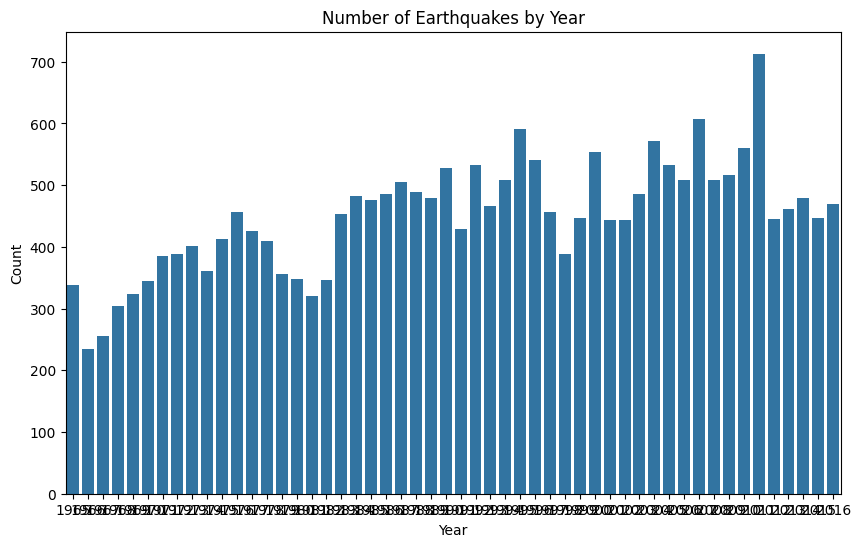

In [65]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Year', data=df)
plt.title('Number of Earthquakes by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Year'>

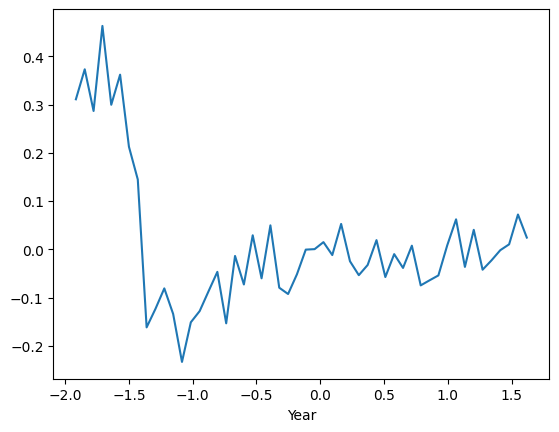

In [104]:
df.groupby('Year')['Magnitude'].mean().plot()

<Axes: xlabel='Month'>

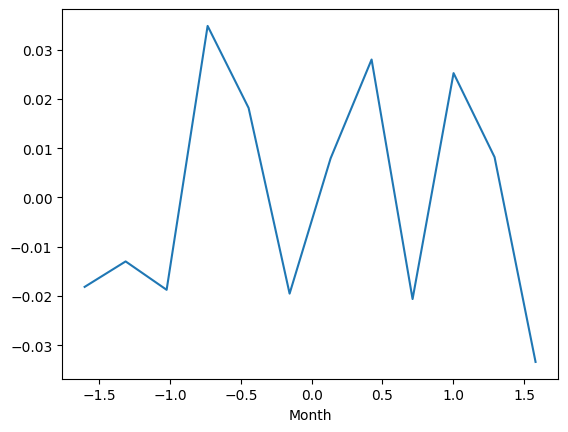

In [105]:
df.groupby('Month')['Magnitude'].mean().plot()

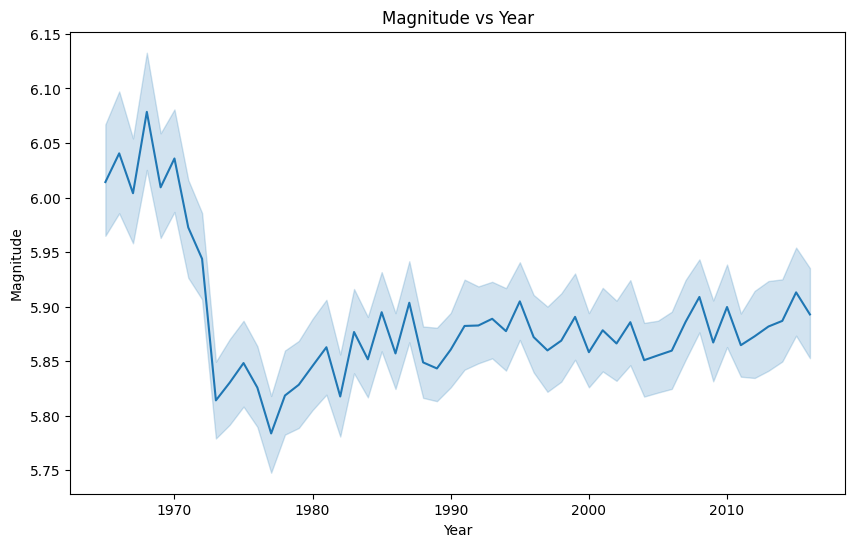

In [66]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Magnitude')
plt.title('Magnitude vs Year')
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.show()

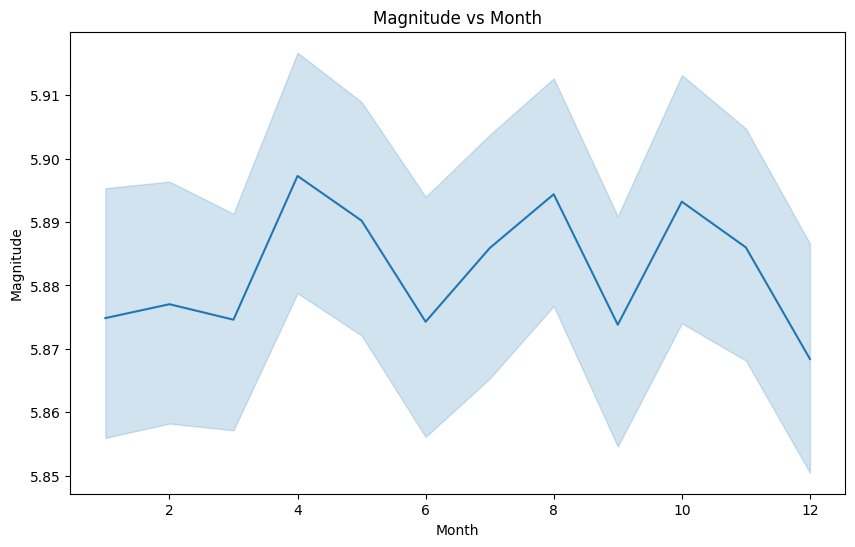

In [67]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Month', y='Magnitude')
plt.title('Magnitude vs Month')
plt.xlabel('Month')
plt.ylabel('Magnitude')
plt.show()

## 7. Encoding & Scaling

In [68]:
label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])
df['Location Source'] = label_encoder.fit_transform(df['Location Source'])
df['Magnitude Source'] = label_encoder.fit_transform(df['Magnitude Source'])
df['Status'] = label_encoder.fit_transform(df['Status'])
df['Magnitude Type'] = label_encoder.fit_transform(df['Magnitude Type'])

In [69]:
scaler = StandardScaler()

for column in df.columns:
    df[column] = scaler.fit_transform(df[column].values.reshape(-1, 1))

## 8. Final Dataset

In [70]:
df.head(5)

,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,Location Source,Magnitude Source,Status,Year,Month,Day,Hour,Minute,Second
0,0.583377,0.844368,-0.087714,0.495984,0.277668,-0.018712,-2.503872,-0.697041,-2.805627,-1.915487,-1.603109,-1.577919,0.225244,0.845244,-0.663948
1,0.006109,0.698849,-0.087714,0.075272,-0.195082,-0.018712,-2.503872,-0.697041,-2.805627,-1.915487,-1.603109,-1.347254,-0.064982,-0.016550,1.116487
2,-0.739162,-1.701962,-0.087714,-0.413928,0.750418,-0.018712,-2.503872,-0.697041,-2.805627,-1.915487,-1.603109,-1.231922,0.950811,-1.395420,1.633387
3,-2.017599,-0.503524,-0.087714,-0.454694,-0.195082,-0.018712,-2.503872,-0.697041,-2.805627,-1.915487,-1.603109,-0.885924,0.950811,1.132509,0.771887
4,0.340688,0.691479,-0.087714,-0.454694,-0.195082,-0.018712,-2.503872,-0.697041,-2.805627,-1.915487,-1.603109,-0.770592,0.225244,0.155809,1.173920
